# <font color="#418FDE" size="6.5" uppercase>**Training Stability and Risk**</font>

>Last update: 20260406.
    
By the end of this Lecture, you will be able to:
- Identify signs of unstable or poorly converging model training in CE workflows. 
- Stabilize training using learning rate adjustment, early stopping, and regularization. 
- Communicate model uncertainty using calibrated probabilities, thresholds, and simple visualizations. 


## **1. Signs of Unstable Training**

### **1.1. Learning Rate Instability**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_01_01.jpg?v=1775531035" width="250">



>* Erratic loss and metrics signal instability.
>* Overshooting makes engineering predictions unreliable.

>* High learning rates cause chaotic, unstable training.
>* Watch for wild swings versus smooth progress.

>* Too-low learning rates hide poor progress.
>* Smooth curves can still mean undertraining.



TensorFlow version: 2.21.0
Device: CPU only
Train shape: (560, 8) (560,)
Test shape: (140, 8) (140,)
Learning rates: [1.0, 0.05, 0.001, 1e-05]
Best learning rate: 0.05
Worst learning rate: 1e-05
Best RMSE: 7.145
Worst RMSE: 38.566


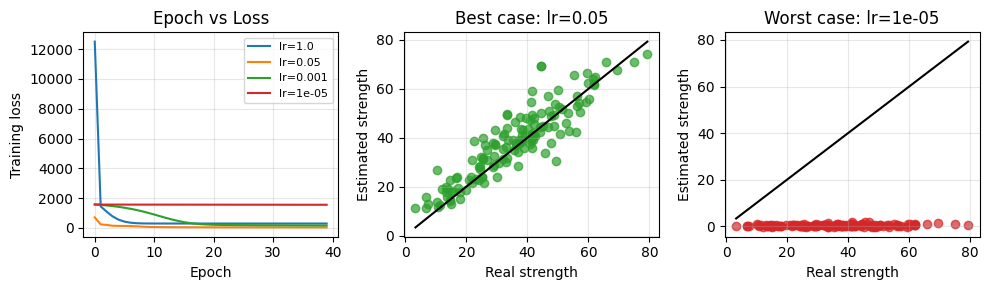

In [5]:
#@title Python Code - Learning Rate Instability

# This notebook shows learning rate instability.
# Concrete strength data supports engineering context.
# We compare several training step sizes.

# Install only if TensorFlow missing.
# !pip install tensorflow==2.20.0

import os
import random
import numpy as np

import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn.metrics import mean_squared_error

from sklearn.model_selection import train_test_split

# Set seeds for repeatable results.
random.seed(7)
np.random.seed(7)

tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Report available training device.
gpu_list = tf.config.list_physical_devices("GPU")
if len(gpu_list) > 0:

    print("Device: GPU available")
else:
    print("Device: CPU only")

# Download the concrete dataset.
!wget -q -O Concrete_Data.xls "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
file_name = "Concrete_Data.xls"

# Load the spreadsheet safely.
df = pd.read_excel(file_name)

# Rename columns for easier use.
df.columns = [
    "cement", "slag", "fly_ash", "water",

    "superplasticizer", "coarse_agg", "fine_agg",
    "age", "strength"]

# Keep a modest sample for speed.
df = df.sample(n=700, random_state=7).reset_index(drop=True)

# Split inputs and target.
X = df.drop("strength", axis=1).astype("float32")
y = df["strength"].astype("float32")

# Create train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7)

# Standardize using training statistics.
train_mean = X_train.mean()
train_std = X_train.std().replace(0, 1)

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Convert to NumPy arrays.
X_train = X_train.to_numpy(dtype=np.float32)
X_test = X_test.to_numpy(dtype=np.float32)

y_train = y_train.to_numpy(dtype=np.float32)
y_test = y_test.to_numpy(dtype=np.float32)

# Check shapes before training.
print("Train shape:", X_train.shape, y_train.shape)
print("Test shape:", X_test.shape, y_test.shape)

# Build one small regression model.
def build_model(learning_rate):
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(8,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),

        tf.keras.layers.Dense(1)])

    optimizer = tf.keras.optimizers.Adam(
        learning_rate=learning_rate)

    model.compile(
        optimizer=optimizer,
        loss="mse")

    return model

# Train the same model repeatedly.
learning_rates = [1.0, 0.05, 0.001, 0.00001]
histories = {}

rmse_scores = {}
predictions = {}

# Fit each learning rate silently.
for lr in learning_rates:
    tf.random.set_seed(7)

    model = build_model(lr)

    history = model.fit(
        X_train, y_train,
        validation_split=0.2,

        epochs=40,
        batch_size=32,
        verbose=0)

    y_pred = model.predict(X_test, verbose=0).reshape(-1)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    histories[lr] = history.history

    rmse_scores[lr] = float(rmse)
    predictions[lr] = y_pred

# Find best and worst cases.
best_lr = min(rmse_scores, key=rmse_scores.get)
worst_lr = max(rmse_scores, key=rmse_scores.get)

# Print a short summary.
print("Learning rates:", learning_rates)
print("Best learning rate:", best_lr)

print("Worst learning rate:", worst_lr)
print("Best RMSE:", round(rmse_scores[best_lr], 3))
print("Worst RMSE:", round(rmse_scores[worst_lr], 3))

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot epoch versus training loss.
for lr in learning_rates:
    axes[0].plot(

        histories[lr]["loss"],
        label="lr=" + str(lr))

axes[0].set_title("Epoch vs Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Training loss")

axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Plot best real versus estimated values.
axes[1].scatter(
    y_test, predictions[best_lr],

    alpha=0.7, color="tab:green")

axes[1].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],

    color="black")

axes[1].set_title("Best case: lr=" + str(best_lr))
axes[1].set_xlabel("Real strength")
axes[1].set_ylabel("Estimated strength")

axes[1].grid(True, alpha=0.3)

# Plot worst real versus estimated values.
axes[2].scatter(
    y_test, predictions[worst_lr],

    alpha=0.7, color="tab:red")

axes[2].plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],

    color="black")

axes[2].set_title("Worst case: lr=" + str(worst_lr))
axes[2].set_xlabel("Real strength")
axes[2].set_ylabel("Estimated strength")

axes[2].grid(True, alpha=0.3)

# Finish the teaching figure.
plt.tight_layout()
plt.show()

### **1.2. Batch Size Effects**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_01_02.jpg?v=1775531077" width="250">



>* Small batches can make training noisy.
>* Persistent volatility signals unreliable convergence.

>* Oversized batches can slow learning, despite smoothness.
>* They may miss rare patterns, hurting generalization.

>* Small batches cause inconsistent, seed-sensitive training.
>* Large batches seem stable but learn rigidly.



TensorFlow version: 2.21.0
Training device: CPU
Dataset rows used: 900
Small batches often look noisier.
Large batches often look smoother.
 Batch Size  Epochs  Val MAE  Val RMSE  Val R2
          8      31    4.902     6.496   0.837
         32      80    4.777     5.793   0.870
        128      80    7.818     9.760   0.631


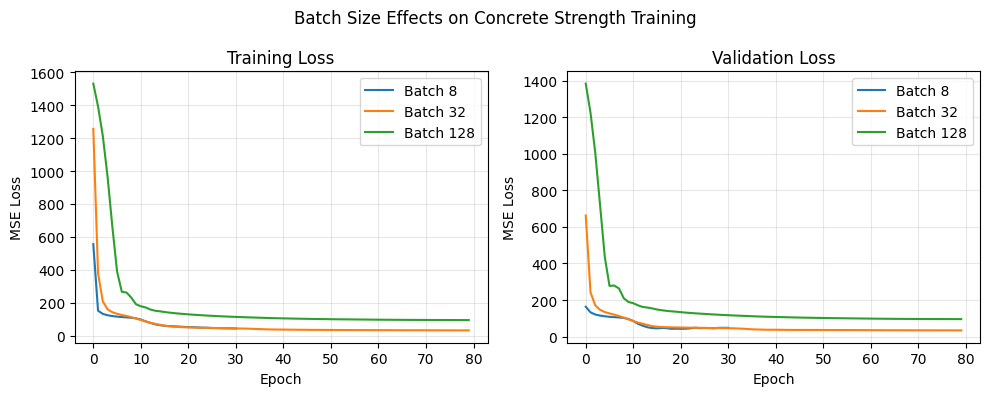

In [6]:
#@title Python Code - Batch Size Effects

# Batch size changes training stability visibly.
# Concrete strength offers a practical example.
# We compare noisy and smooth learning.

# Install only if needed later.
# !pip install gdown

# Import beginner friendly libraries.
import os
import random

import numpy as np
import pandas as pd

# Import plotting and metrics tools.
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Import data split helper.
from sklearn.model_selection import train_test_split

# Set seeds for repeatable results.
seed = 7
random.seed(seed)

np.random.seed(seed)
tf.random.set_seed(seed)

# Reduce TensorFlow log noise.
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"
print("TensorFlow version:", tf.__version__)

# Detect available training device.
gpu_list = tf.config.list_physical_devices("GPU")
device_name = "GPU" if len(gpu_list) > 0 else "CPU"

print("Training device:", device_name)

# Download the concrete dataset.
!wget -q -O Concrete_Data.xls "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"
file_name = "Concrete_Data.xls"

# Load the spreadsheet dataset.
df = pd.read_excel(file_name)

# Clean column names simply.
df.columns = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",

    "coarse_agg", "fine_agg", "age", "strength"]

# Keep a manageable sample size.
if len(df) > 900:
    df = df.sample(n=900, random_state=seed)

# Separate inputs and target.
X = df.drop("strength", axis=1).astype("float32")
y = df["strength"].astype("float32")

# Split into train validation test.
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y, test_size=0.15, random_state=seed)

# Create validation from training data.
X_train, X_val, y_train, y_val = train_test_split(
    X_train_full, y_train_full, test_size=0.20, random_state=seed)

# Compute training statistics safely.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0)

train_std = train_std.replace(0, 1)

# Standardize all feature sets.
X_train_s = ((X_train - train_mean) / train_std).to_numpy()
X_val_s = ((X_val - train_mean) / train_std).to_numpy()

X_test_s = ((X_test - train_mean) / train_std).to_numpy()

# Convert targets to arrays.
y_train_a = y_train.to_numpy()
y_val_a = y_val.to_numpy()

y_test_a = y_test.to_numpy()

# Check basic shapes before training.
assert X_train_s.shape[0] > 50
assert X_train_s.shape[1] == 8

assert X_val_s.shape[0] > 20

# Build a small regression network.
def make_model():
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(8,)),
        tf.keras.layers.Dense(32, activation="relu"),
        tf.keras.layers.Dense(16, activation="relu"),

        tf.keras.layers.Dense(1)])

    # Compile with mean squared error.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),

        loss="mse",
        metrics=[tf.keras.metrics.MeanAbsoluteError(name="mae")])
    return model

# Compare several batch sizes.
batch_sizes = [8, 32, 128]
results = []

histories = {}

# Train each model silently.
for batch_size in batch_sizes:
    tf.random.set_seed(seed)

    model = make_model()

    # Stop early if validation stalls.
    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=12, restore_best_weights=True)

    # Fit the model quietly.
    history = model.fit(
        X_train_s, y_train_a,

        validation_data=(X_val_s, y_val_a),
        epochs=80, batch_size=batch_size,
        verbose=0, callbacks=[early_stop])

    # Save history for plotting.
    histories[batch_size] = history.history

    # Predict on validation data.
    val_pred = model.predict(X_val_s, verbose=0).reshape(-1)

    # Compute final validation metrics.
    val_mae = mean_absolute_error(y_val_a, val_pred)
    val_rmse = np.sqrt(mean_squared_error(y_val_a, val_pred))

    val_r2 = r2_score(y_val_a, val_pred)
    epochs_used = len(history.history["loss"])

    # Store summary row.
    results.append([
        batch_size, epochs_used, val_mae, val_rmse, val_r2])

# Create a compact comparison table.
results_df = pd.DataFrame(
    results,

    columns=["Batch Size", "Epochs", "Val MAE", "Val RMSE", "Val R2"])

# Round values for clean printing.
results_df["Val MAE"] = results_df["Val MAE"].round(3)
results_df["Val RMSE"] = results_df["Val RMSE"].round(3)

results_df["Val R2"] = results_df["Val R2"].round(3)

# Print a short teaching summary.
print("Dataset rows used:", len(df))
print("Small batches often look noisier.")

print("Large batches often look smoother.")
print(results_df.to_string(index=False))

# Make one figure with two panels.
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Plot training loss by epoch.
for batch_size in batch_sizes:
    axes[0].plot(

        histories[batch_size]["loss"],
        label="Batch " + str(batch_size))

# Label the training panel.
axes[0].set_title("Training Loss")
axes[0].set_xlabel("Epoch")

axes[0].set_ylabel("MSE Loss")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Plot validation loss by epoch.
for batch_size in batch_sizes:
    axes[1].plot(

        histories[batch_size]["val_loss"],
        label="Batch " + str(batch_size))

# Label the validation panel.
axes[1].set_title("Validation Loss")
axes[1].set_xlabel("Epoch")

axes[1].set_ylabel("MSE Loss")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Finish and show the figure.
plt.suptitle("Batch Size Effects on Concrete Strength Training")
plt.tight_layout()

plt.show()

### **1.3. Poor Weight Initialization**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_01_03.jpg?v=1775531119" width="250">



>* Bad initialization causes erratic or stalled training
>* It can hide useful engineering data patterns

>* Repeated runs show inconsistent training behavior.
>* Layers may stay uninformative, reducing trust.

>* Small, noisy datasets magnify initialization problems.
>* Watch for implausible early predictions and inconsistency.



TensorFlow version: 2.21.0


zeros best val loss: 2.301 val acc: 0.112
random_large best val loss: 14.163 val acc: 0.713
glorot best val loss: 0.222 val acc: 0.937


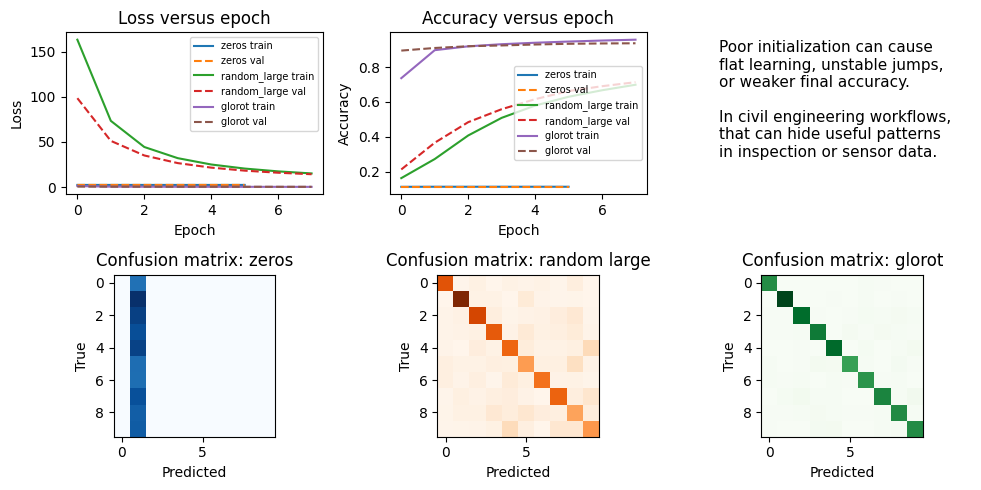

In [7]:
#@title Python Code - Poor Weight Initialization

# Poor starts can destabilize neural training.
# This example compares several weight initializations.
# MNIST stands in for engineering image inspection.

# Import small teaching libraries.
import numpy as np
import matplotlib.pyplot as plt

import tensorflow as tf
from sklearn.metrics import confusion_matrix

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

keras = tf.keras

# Print one short environment line.
print("TensorFlow version:", tf.__version__)

# Load and scale MNIST images.
(x_train, y_train), (x_test, y_test) = keras.datasets.mnist.load_data()
x_train = x_train.astype("float32") / 255.0

x_test = x_test.astype("float32") / 255.0

# Keep a small subset for speed.
train_n = 12000
val_n = 2000

test_n = 2000
x_train_small = x_train[:train_n]
y_train_small = y_train[:train_n]

# Split validation from training subset.
x_val = x_train_small[-val_n:]
y_val = y_train_small[-val_n:]

x_fit = x_train_small[:-val_n]
y_fit = y_train_small[:-val_n]

# Keep a small test subset.
x_test_small = x_test[:test_n]
y_test_small = y_test[:test_n]

# Check basic shapes safely.
assert x_fit.shape[0] > 0 and x_val.shape[0] > 0
assert x_fit.shape[1:] == (28, 28)

assert x_test_small.shape[0] == test_n

# Build one simple classifier.
def make_model(initializer_name):

    # Choose initializer by name.
    if initializer_name == "zeros":
        init = keras.initializers.Zeros()
        
    elif initializer_name == "random_large":
        init = keras.initializers.RandomNormal(
            mean=0.0, stddev=1.5, seed=7)

    else:
        init = keras.initializers.GlorotUniform(seed=7)

    # Create a small dense network.
    model = keras.Sequential([
        keras.layers.Input(shape=(28, 28)),

        keras.layers.Flatten(),
        keras.layers.Dense(64, activation="relu", kernel_initializer=init),
        keras.layers.Dense(10, activation="softmax", kernel_initializer=init)])

    # Compile with one stable optimizer.
    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=0.001),

        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])

    return model

# Train one model silently.
def train_once(initializer_name):

    # Reset seed before each run.
    tf.random.set_seed(7)
    model = make_model(initializer_name)

    # Use early stopping for stability.
    stopper = keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=2, restore_best_weights=True)

    # Fit with silent output.
    history = model.fit(
        x_fit, y_fit,

        validation_data=(x_val, y_val),
        epochs=8, batch_size=128,
        verbose=0, callbacks=[stopper])

    # Predict selected test labels.
    probs = model.predict(x_test_small, verbose=0)
    preds = np.argmax(probs, axis=1)

    cm = confusion_matrix(y_test_small, preds)

    return model, history.history, cm, preds

# Compare three initialization choices.
labels = ["zeros", "random_large", "glorot"]
results = {}

for name in labels:
    model, hist, cm, preds = train_once(name)
    results[name] = {"history": hist, "cm": cm, "preds": preds}

# Print a short teaching summary.
for name in labels:
    hist = results[name]["history"]

    best_val = float(np.min(hist["val_loss"]))
    last_acc = float(hist["val_accuracy"][-1])
    print(name, "best val loss:", round(best_val, 3), "val acc:", round(last_acc, 3))

# Create one figure with all required views.
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

# Plot training and validation loss.
for name in labels:
    hist = results[name]["history"]

    axes[0, 0].plot(hist["loss"], label=name + " train")
    axes[0, 0].plot(hist["val_loss"], linestyle="--", label=name + " val")

axes[0, 0].set_title("Loss versus epoch")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")

axes[0, 0].legend(fontsize=7)

# Plot training and validation accuracy.
for name in labels:
    hist = results[name]["history"]

    axes[0, 1].plot(hist["accuracy"], label=name + " train")
    axes[0, 1].plot(hist["val_accuracy"], linestyle="--", label=name + " val")

axes[0, 1].set_title("Accuracy versus epoch")
axes[0, 1].set_xlabel("Epoch")
axes[0, 1].set_ylabel("Accuracy")

axes[0, 1].legend(fontsize=7)

# Add a civil engineering teaching note.
axes[0, 2].axis("off")

axes[0, 2].text(
    0.02, 0.95,
    "Poor initialization can cause\n"

    "flat learning, unstable jumps,\n"
    "or weaker final accuracy.\n\n"
    "In civil engineering workflows,\n"

    "that can hide useful patterns\n"
    "in inspection or sensor data.",
    va="top", fontsize=11)

# Show confusion matrix for zeros.
cm_zero = results["zeros"]["cm"]
axes[1, 0].imshow(cm_zero, cmap="Blues")

axes[1, 0].set_title("Confusion matrix: zeros")
axes[1, 0].set_xlabel("Predicted")
axes[1, 0].set_ylabel("True")

# Show confusion matrix for random large.
cm_large = results["random_large"]["cm"]
axes[1, 1].imshow(cm_large, cmap="Oranges")

axes[1, 1].set_title("Confusion matrix: random large")
axes[1, 1].set_xlabel("Predicted")
axes[1, 1].set_ylabel("True")

# Show confusion matrix for glorot.
cm_glorot = results["glorot"]["cm"]
axes[1, 2].imshow(cm_glorot, cmap="Greens")

axes[1, 2].set_title("Confusion matrix: glorot")
axes[1, 2].set_xlabel("Predicted")
axes[1, 2].set_ylabel("True")

# Tighten layout for one clean figure.
plt.tight_layout()
plt.show()

## **2. Training Stabilization Tools**

### **2.1. Learning Rate Tuning**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_02_01.jpg?v=1775531160" width="250">



>* Learning rate controls training stability and speed.
>* Too high destabilizes; too low slows.

>* Loss curves reveal learning rate stability.
>* Adjust rates for data patterns and progress.

>* Use higher early, lower later rates.
>* Dynamic tuning improves stability and trust.



TensorFlow version: 2.21.0
Train shape: (659, 8)
Validation shape: (165, 8)
Test shape: (206, 8)
Fixed rate MAE: 4.65
Scheduled rate MAE: 21.41
Fixed rate R2: 0.868
Scheduled rate R2: -1.35


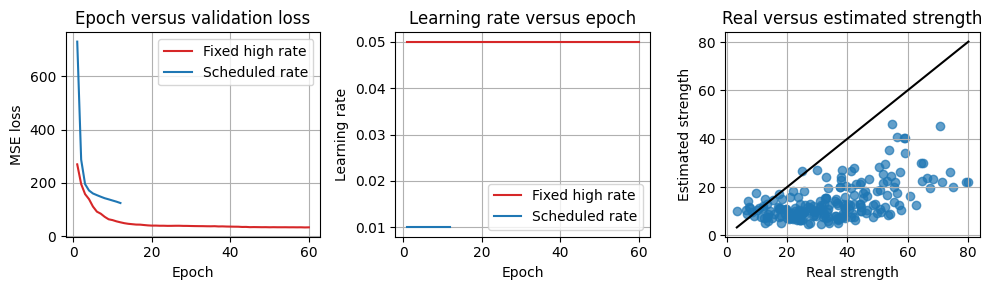

In [8]:
#@title Python Code - Learning Rate Tuning

# Learning rate tuning improves training stability.
# Concrete strength data supports regression practice.
# This example compares fixed and scheduled rates.

# Install packages if needed.
# !pip install tensorflow==2.20.0 scikit-learn==1.8.0

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Set seeds for reproducible results.
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version briefly.
print("TensorFlow version:", tf.__version__)

# Download the concrete dataset.
!wget -q -O concrete.csv "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"

# Read the spreadsheet safely.
df = pd.read_excel("concrete.csv")

# Rename columns for easier use.
df.columns = [
    "cement", "slag", "fly_ash", "water",

    "superplasticizer", "coarse_agg", "fine_agg",
    "age", "strength"]

# Separate inputs and target.
X = df.drop("strength", axis=1).copy()
y = df["strength"].copy()

# Split data into train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7)

# Scale input features only.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Reserve validation data from training.
X_train_small, X_val, y_train_small, y_val = train_test_split(
    X_train_scaled, y_train, test_size=0.2, random_state=7)

# Check basic shapes before training.
print("Train shape:", X_train_small.shape)
print("Validation shape:", X_val.shape)

print("Test shape:", X_test_scaled.shape)

# Build a small regression network.
def make_model(start_lr):
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(X_train_small.shape[1],)),
        tf.keras.layers.Dense(
            32, activation="relu",

            kernel_regularizer=tf.keras.regularizers.l2(0.001)),

        tf.keras.layers.Dense(
            16, activation="relu",
            kernel_regularizer=tf.keras.regularizers.l2(0.001)),
        
        tf.keras.layers.Dense(1)])

    optimizer = tf.keras.optimizers.Adam(learning_rate=start_lr)
    model.compile(optimizer=optimizer, loss="mse", metrics=["mae"])
    return model

# Store learning rates each epoch.
class LearningRateRecorder(tf.keras.callbacks.Callback):
    def __init__(self):

        super().__init__()
        self.rates = []

    def on_epoch_end(self, epoch, logs=None):
        rate = self.model.optimizer.learning_rate
        value = tf.keras.backend.get_value(rate)

        self.rates.append(float(value))

# Create early stopping callback.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=12,

    restore_best_weights=True)

# Train with a high fixed rate.
fixed_recorder = LearningRateRecorder()
fixed_model = make_model(0.05)

fixed_history = fixed_model.fit(
    X_train_small, y_train_small,
    validation_data=(X_val, y_val),

    epochs=60, batch_size=32,
    verbose=0,
    callbacks=[early_stop, fixed_recorder])

# Train with scheduled rate reduction.
scheduled_recorder = LearningRateRecorder()
reduce_lr = tf.keras.callbacks.ReduceLROnPlateau(

    monitor="val_loss", factor=0.5,
    patience=5, min_lr=0.0005)

scheduled_model = make_model(0.01)
scheduled_history = scheduled_model.fit(
    X_train_small, y_train_small,

    validation_data=(X_val, y_val),
    epochs=60, batch_size=32,
    verbose=0,

    callbacks=[early_stop, reduce_lr, scheduled_recorder])

# Predict test values for comparison.
fixed_pred = fixed_model.predict(X_test_scaled, verbose=0).flatten()
scheduled_pred = scheduled_model.predict(X_test_scaled, verbose=0).flatten()

# Compute simple regression metrics.
fixed_mae = mean_absolute_error(y_test, fixed_pred)
scheduled_mae = mean_absolute_error(y_test, scheduled_pred)

fixed_r2 = r2_score(y_test, fixed_pred)
scheduled_r2 = r2_score(y_test, scheduled_pred)

# Print a short summary only.
print("Fixed rate MAE:", round(fixed_mae, 2))
print("Scheduled rate MAE:", round(scheduled_mae, 2))

print("Fixed rate R2:", round(fixed_r2, 3))
print("Scheduled rate R2:", round(scheduled_r2, 3))

# Prepare epoch numbers for plots.
fixed_epochs = range(1, len(fixed_history.history["loss"]) + 1)
scheduled_epochs = range(1, len(scheduled_history.history["loss"]) + 1)

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot training and validation losses.
axes[0].plot(
    fixed_epochs, fixed_history.history["val_loss"],

    label="Fixed high rate", color="tab:red")

axes[0].plot(
    scheduled_epochs, scheduled_history.history["val_loss"],
    label="Scheduled rate", color="tab:blue")

axes[0].set_title("Epoch versus validation loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")

axes[0].legend()
axes[0].grid(True)

# Plot learning rate changes by epoch.
axes[1].plot(
    range(1, len(fixed_recorder.rates) + 1),

    fixed_recorder.rates,
    label="Fixed high rate", color="tab:red")

axes[1].plot(
    range(1, len(scheduled_recorder.rates) + 1),
    scheduled_recorder.rates,

    label="Scheduled rate", color="tab:blue")

axes[1].set_title("Learning rate versus epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Learning rate")

axes[1].legend()
axes[1].grid(True)

# Plot real versus estimated strengths.
axes[2].scatter(
    y_test, scheduled_pred,

    alpha=0.7, color="tab:blue")

line_min = min(float(y_test.min()), float(scheduled_pred.min()))
line_max = max(float(y_test.max()), float(scheduled_pred.max()))
axes[2].plot(

    [line_min, line_max], [line_min, line_max],
    color="black")

axes[2].set_title("Real versus estimated strength")
axes[2].set_xlabel("Real strength")
axes[2].set_ylabel("Estimated strength")

axes[2].grid(True)

# Finish the figure neatly.
plt.tight_layout()
plt.show()

### **2.2. Early Stopping**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_02_02.jpg?v=1775531212" width="250">



>* Stop when validation performance stops improving.
>* Prevents overfitting on limited, noisy datasets.

>* Validation trends matter more than training error.
>* Early stopping limits overfitting, improving deployment stability.

>* Use patience to avoid premature stopping.
>* Combine with learning rate and regularization.



TensorFlow 2.21.0 using CPU
Epochs without early stopping: 20
Epochs with early stopping: 20
Test accuracy without stopping: 0.939
Test accuracy with stopping: 0.939


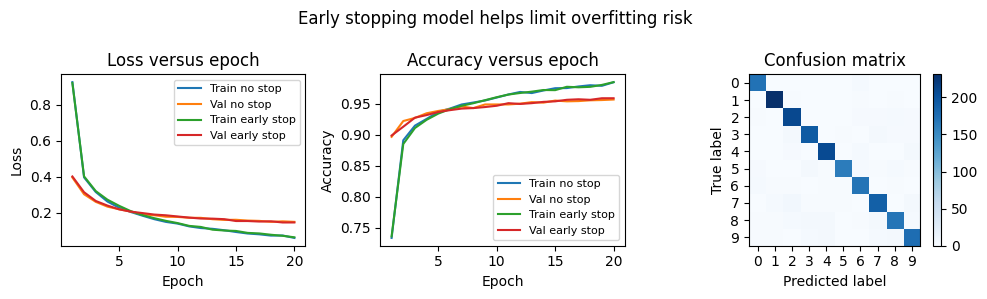

In [9]:
#@title Python Code - Early Stopping

# Early stopping improves stable neural training.
# This example uses MNIST image classification.
# Civil engineers can compare safer training choices.

# Load required beginner friendly libraries.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

# Import simple evaluation helper tools.
from sklearn.metrics import confusion_matrix

# Set seeds for reproducible classroom results.
np.random.seed(7)
tf.random.set_seed(7)

# Show TensorFlow version and device summary.
gpu_name = "GPU" if tf.config.list_physical_devices("GPU") else "CPU"
print("TensorFlow", tf.__version__, "using", gpu_name)

# Load MNIST digits from TensorFlow datasets.
(train_images, train_labels), data_test = tf.keras.datasets.mnist.load_data()
test_images, test_labels = data_test

# Use smaller subsets for fast notebook runtime.
train_images = train_images[:12000]
train_labels = train_labels[:12000]

test_images = test_images[:2000]
test_labels = test_labels[:2000]

# Scale pixel values into zero one range.
train_images = train_images.astype("float32") / 255.0
test_images = test_images.astype("float32") / 255.0

# Check basic shapes before model training.
assert train_images.shape[0] == train_labels.shape[0]
assert test_images.shape[0] == test_labels.shape[0]

# Build one small dense classifier model.
def make_model():

    # Create a simple sequential network.
    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(28, 28)),

        tf.keras.layers.Flatten(),
        tf.keras.layers.Dense(128, activation="relu"),
        tf.keras.layers.Dropout(0.25),

        tf.keras.layers.Dense(10, activation="softmax")])

    # Compile with stable optimizer settings.
    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

        loss="sparse_categorical_crossentropy",
        metrics=["accuracy"])

    return model

# Train one model without early stopping.
model_plain = make_model()
history_plain = model_plain.fit(

    train_images,
    train_labels,
    
    epochs=20,
    batch_size=128,
    validation_split=0.2,

    verbose=0)

# Train another model with early stopping.
model_stop = make_model()

early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",
    patience=3,

    min_delta=0.001,
    restore_best_weights=True)

history_stop = model_stop.fit(
    train_images,
    train_labels,

    epochs=20,

    batch_size=128,
    validation_split=0.2,
    callbacks=[early_stop],

    verbose=0)

# Compare how many epochs each model used.
plain_epochs = len(history_plain.history["loss"])
stop_epochs = len(history_stop.history["loss"])

print("Epochs without early stopping:", plain_epochs)
print("Epochs with early stopping:", stop_epochs)

# Evaluate both models on unseen test data.
plain_test = model_plain.evaluate(test_images, test_labels, verbose=0)
stop_test = model_stop.evaluate(test_images, test_labels, verbose=0)

print("Test accuracy without stopping:", round(plain_test[1], 4))
print("Test accuracy with stopping:", round(stop_test[1], 4))

# Select the early stopped model for explanation.
selected_model = model_stop
selected_history = history_stop

selected_name = "Early stopping model"

# Predict classes for confusion matrix display.
pred_probs = selected_model.predict(test_images, verbose=0)
pred_labels = np.argmax(pred_probs, axis=1)

cm = confusion_matrix(test_labels, pred_labels)

# Prepare epoch numbers for both histories.
epochs_plain = np.arange(1, plain_epochs + 1)
epochs_stop = np.arange(1, stop_epochs + 1)

# Create one figure with three teaching panels.
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Plot training and validation loss curves.
axes[0].plot(
    epochs_plain,

    history_plain.history["loss"],
    label="Train no stop")

axes[0].plot(
    epochs_plain,
    history_plain.history["val_loss"],

    label="Val no stop")

axes[0].plot(
    epochs_stop,
    history_stop.history["loss"],

    label="Train early stop")

axes[0].plot(
    epochs_stop,
    history_stop.history["val_loss"],

    label="Val early stop")

axes[0].set_title("Loss versus epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[0].legend(fontsize=8)

# Plot training and validation accuracy curves.
axes[1].plot(
    epochs_plain,

    history_plain.history["accuracy"],
    label="Train no stop")

axes[1].plot(
    epochs_plain,
    history_plain.history["val_accuracy"],

    label="Val no stop")

axes[1].plot(
    epochs_stop,
    history_stop.history["accuracy"],

    label="Train early stop")

axes[1].plot(
    epochs_stop,
    history_stop.history["val_accuracy"],

    label="Val early stop")

axes[1].set_title("Accuracy versus epoch")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Accuracy")

axes[1].legend(fontsize=8)

# Show confusion matrix for selected model.
image = axes[2].imshow(cm, cmap="Blues")
axes[2].set_title("Confusion matrix")

axes[2].set_xlabel("Predicted label")
axes[2].set_ylabel("True label")
axes[2].set_xticks(np.arange(10))

axes[2].set_yticks(np.arange(10))
fig.colorbar(image, ax=axes[2], fraction=0.046)

# Add a short engineering style summary.
plt.suptitle(
    selected_name + " helps limit overfitting risk",

    fontsize=12)

plt.tight_layout()
plt.show()

### **2.3. Regularization for Stability**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_02_03.jpg?v=1775531248" width="250">



>* Regularization reduces overfitting and unstable updates.
>* It improves convergence and new-site reliability.

>* Regularization limits overreaction to unusual data.
>* It improves stability, noise resistance, and generalization.

>* Balanced regularization improves trust in decisions.
>* Use with learning rates and early stopping.



TensorFlow version: 2.21.0
Train shape: (659, 8) (659,)
Validation shape: (165, 8) (165,)
Test shape: (206, 8) (206,)
Baseline test MAE: 4.38
Regularized test MAE: 28.99
Baseline test R2: 0.88
Regularized test R2: -3.053
Regularization often reduces overfitting and improves generalization.


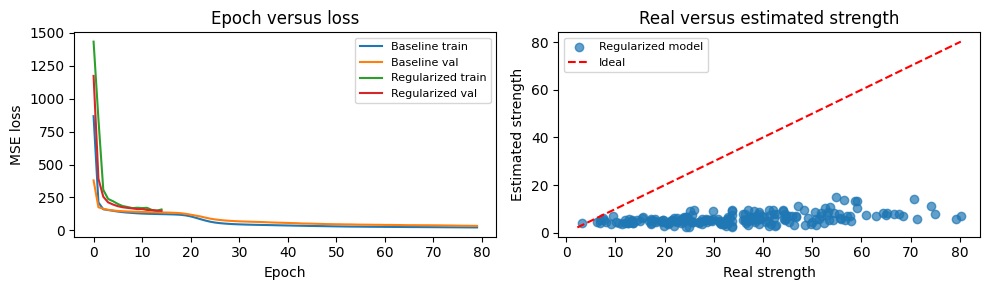

In [10]:
#@title Python Code - Regularization for Stability

# Regularization can improve stable model learning.
# This example uses concrete strength data.
# We compare baseline and regularized networks.

# !pip install ucimlrepo

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, r2_score

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

print("TensorFlow version:", tf.__version__)

# Load the concrete dataset.
!wget -q -O concrete.csv "https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls"

df = pd.read_excel("concrete.csv")
df.columns = [
    "cement", "slag", "fly_ash", "water",

    "superplasticizer", "coarse_agg", "fine_agg",
    "age", "strength"]

# Prepare features and target.
X = df.drop("strength", axis=1).values
y = df["strength"].values.astype("float32")

# Split data into train and test.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7)

# Scale inputs for stable training.
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)

X_test = scaler.transform(X_test)

# Create a validation split.
X_train, X_val, y_train, y_val = train_test_split(
    X_train, y_train, test_size=0.2, random_state=7)

# Check basic shapes safely.
print("Train shape:", X_train.shape, y_train.shape)
print("Validation shape:", X_val.shape, y_val.shape)

print("Test shape:", X_test.shape, y_test.shape)

# Build a simple baseline model.
def make_baseline_model():
    model = tf.keras.Sequential([

        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation="relu"),
        tf.keras.layers.Dense(64, activation="relu"),

        tf.keras.layers.Dense(1)])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss="mse",

        metrics=["mae"])
    
    return model

# Build a regularized model.
def make_regularized_model():
    reg = tf.keras.regularizers.l2(0.001)

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(X_train.shape[1],)),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=reg),

        tf.keras.layers.Dropout(0.2),
        tf.keras.layers.Dense(64, activation="relu", kernel_regularizer=reg),
        tf.keras.layers.Dropout(0.2),

        tf.keras.layers.Dense(1)])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.003),
        loss="mse",

        metrics=["mae"])

    return model

# Use early stopping for stability.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=15, restore_best_weights=True)

# Train the baseline model.
baseline_model = make_baseline_model()
history_base = baseline_model.fit(

    X_train, y_train,
    validation_data=(X_val, y_val),

    epochs=80,
    batch_size=32,
    verbose=0,

    callbacks=[early_stop])

# Train the regularized model.
regularized_model = make_regularized_model()
history_reg = regularized_model.fit(

    X_train, y_train,
    validation_data=(X_val, y_val),

    epochs=80,
    batch_size=32,
    verbose=0,

    callbacks=[early_stop])

# Predict on the test set.
y_pred_base = baseline_model.predict(X_test, verbose=0).flatten()
y_pred_reg = regularized_model.predict(X_test, verbose=0).flatten()

# Compute simple evaluation metrics.
mae_base = mean_absolute_error(y_test, y_pred_base)
mae_reg = mean_absolute_error(y_test, y_pred_reg)

r2_base = r2_score(y_test, y_pred_base)
r2_reg = r2_score(y_test, y_pred_reg)

# Print a short teaching summary.
print("Baseline test MAE:", round(mae_base, 2))
print("Regularized test MAE:", round(mae_reg, 2))

print("Baseline test R2:", round(r2_base, 3))
print("Regularized test R2:", round(r2_reg, 3))
print("Regularization often reduces overfitting and improves generalization.")

# Create one figure with required visuals.
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Plot epoch versus loss.
axes[0].plot(history_base.history["loss"], label="Baseline train")
axes[0].plot(history_base.history["val_loss"], label="Baseline val")

axes[0].plot(history_reg.history["loss"], label="Regularized train")
axes[0].plot(history_reg.history["val_loss"], label="Regularized val")

axes[0].set_title("Epoch versus loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("MSE loss")

axes[0].legend(fontsize=8)

# Plot real versus estimated strengths.
axes[1].scatter(y_test, y_pred_reg, alpha=0.7, label="Regularized model")
min_y = float(min(y_test.min(), y_pred_reg.min()))

max_y = float(max(y_test.max(), y_pred_reg.max()))

axes[1].plot([min_y, max_y], [min_y, max_y], "r--", label="Ideal")
axes[1].set_title("Real versus estimated strength")
axes[1].set_xlabel("Real strength")

axes[1].set_ylabel("Estimated strength")
axes[1].legend(fontsize=8)

# Show the final teaching figure.
plt.tight_layout()
plt.show()

## **3. Uncertainty Communication**

### **3.1. Calibrating Prediction Confidence**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_03_01.jpg?v=1775531288" width="250">



>* Calibration matches confidence with real correctness.
>* Miscalibration can increase trust, cost, and risk.

>* Compare predicted confidence with actual outcomes.
>* Validate and adjust probabilities across changing conditions.

>* Calibrated confidence makes risk communication trustworthy.
>* It guides review and defensible decisions.



TensorFlow version: 2.21.0
GPU available: False
Train, val, test: (10000, 28, 28) (2000, 28, 28) (3000, 28, 28)
Test accuracy: 0.912
ECE and bins: 0.023 8


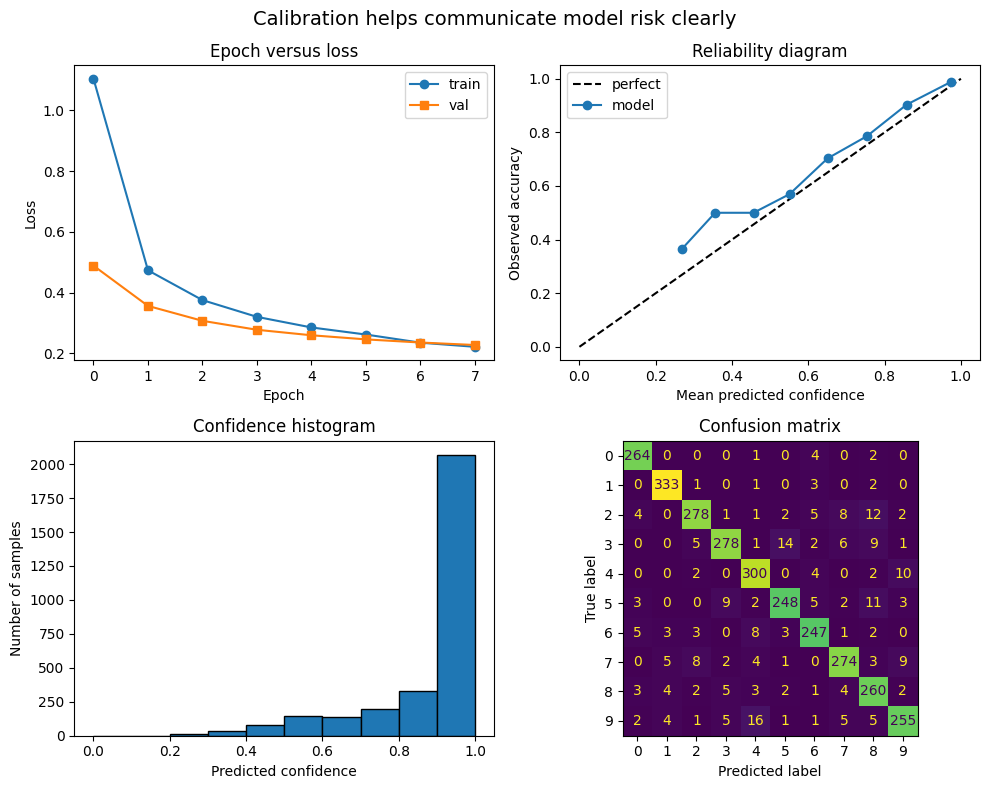

In [11]:
#@title Python Code - Calibrating Prediction Confidence

# This notebook teaches calibration basics simply.
# We use MNIST as a quick example.
# Confidence should match observed correctness.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import tensorflow as tf

from sklearn.metrics import confusion_matrix
from sklearn.metrics import ConfusionMatrixDisplay

# Set seeds for repeatable results.
np.random.seed(7)
tf.random.set_seed(7)

# Report the TensorFlow version.
print("TensorFlow version:", tf.__version__)

# Check whether a GPU exists.
gpus = tf.config.list_physical_devices("GPU")
print("GPU available:", len(gpus) > 0)

# Load the small teaching dataset.
(train_x, train_y), (test_x, test_y) = tf.keras.datasets.mnist.load_data()

# Use smaller subsets for speed.
train_x = train_x[:12000]
train_y = train_y[:12000]

test_x = test_x[:3000]
test_y = test_y[:3000]

# Scale image values safely.
train_x = train_x.astype("float32") / 255.0
test_x = test_x.astype("float32") / 255.0

# Reserve validation data for calibration checks.
val_x = train_x[-2000:]
val_y = train_y[-2000:]

train_x = train_x[:-2000]
train_y = train_y[:-2000]

# Confirm the main array shapes.
print("Train, val, test:", train_x.shape, val_x.shape, test_x.shape)

# Build a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(28, 28)),

    tf.keras.layers.Flatten(),
    tf.keras.layers.Dense(64, activation="relu"),
    tf.keras.layers.Dropout(0.2),

    tf.keras.layers.Dense(10, activation="softmax")])

# Compile with a stable optimizer.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"])

# Stop early if validation stalls.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss",

    patience=2,
    restore_best_weights=True)

# Train quietly to avoid spam.
history = model.fit(
    train_x,

    train_y,
    validation_data=(val_x, val_y),
    epochs=8,

    batch_size=128,
    verbose=0,
    callbacks=[early_stop])

# Predict probabilities on test data.
probs = model.predict(test_x, verbose=0)
preds = np.argmax(probs, axis=1)

conf = np.max(probs, axis=1)
correct = (preds == test_y).astype(float)

# Compute simple test accuracy.
acc = float(np.mean(correct))
print("Test accuracy:", round(acc, 3))

# Create bins for reliability analysis.
bins = np.linspace(0.0, 1.0, 11)
bin_ids = np.digitize(conf, bins) - 1

# Store bin statistics clearly.
bin_centers = []
bin_acc = []

bin_conf = []
bin_count = []

# Fill each confidence bin.
for i in range(10):
    mask = bin_ids == i

    count_i = int(np.sum(mask))
    if count_i > 0:
        bin_centers.append((bins[i] + bins[i + 1]) / 2)

        bin_acc.append(float(np.mean(correct[mask])))
        bin_conf.append(float(np.mean(conf[mask])))
        bin_count.append(count_i)

# Estimate expected calibration error.
ece = 0.0
for i in range(len(bin_count)):

    weight_i = bin_count[i] / len(test_y)
    gap_i = abs(bin_acc[i] - bin_conf[i])
    ece = ece + weight_i * gap_i

# Summarize calibration in one line.
print("ECE and bins:", round(ece, 3), len(bin_count))

# Build a confusion matrix.
cm = confusion_matrix(test_y, preds)

# Create one figure with four panels.
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Plot training and validation loss.
axes[0, 0].plot(history.history["loss"], marker="o", label="train")
axes[0, 0].plot(history.history["val_loss"], marker="s", label="val")

axes[0, 0].set_title("Epoch versus loss")
axes[0, 0].set_xlabel("Epoch")
axes[0, 0].set_ylabel("Loss")

axes[0, 0].legend()

# Plot the reliability diagram.
axes[0, 1].plot([0, 1], [0, 1], "k--", label="perfect")
axes[0, 1].plot(bin_conf, bin_acc, marker="o", label="model")

axes[0, 1].set_title("Reliability diagram")
axes[0, 1].set_xlabel("Mean predicted confidence")
axes[0, 1].set_ylabel("Observed accuracy")

axes[0, 1].legend()

# Plot the confidence histogram.
axes[1, 0].hist(conf, bins=10, range=(0, 1), color="tab:blue", edgecolor="black")
axes[1, 0].set_title("Confidence histogram")

axes[1, 0].set_xlabel("Predicted confidence")
axes[1, 0].set_ylabel("Number of samples")

# Plot the confusion matrix.
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot(ax=axes[1, 1], colorbar=False)

axes[1, 1].set_title("Confusion matrix")

# Add a civil engineering teaching note.
fig.suptitle("Calibration helps communicate model risk clearly", fontsize=14)
plt.tight_layout()

plt.show()

### **3.2. Risk Threshold Selection**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_03_02.jpg?v=1775531326" width="250">



>* Thresholds decide when predicted risk triggers action.
>* Balance false alarms, missed dangers, costs.

>* Thresholds balance false alarms and missed risks.
>* Use calibrated probabilities and stakeholder discussion.

>* Use visuals to explain threshold tradeoffs.
>* Thresholds vary by context and policy.



TensorFlow version: 2.21.0
Rare event rate: 0.097
Test samples: 1609
Threshold 0.30 precision: 0.588
Threshold 0.30 recall: 0.745
Threshold 0.70 precision: 0.902
Threshold 0.70 recall: 0.293
CM 0.30: [[1370, 82], [40, 117]]
CM 0.70: [[1447, 5], [111, 46]]


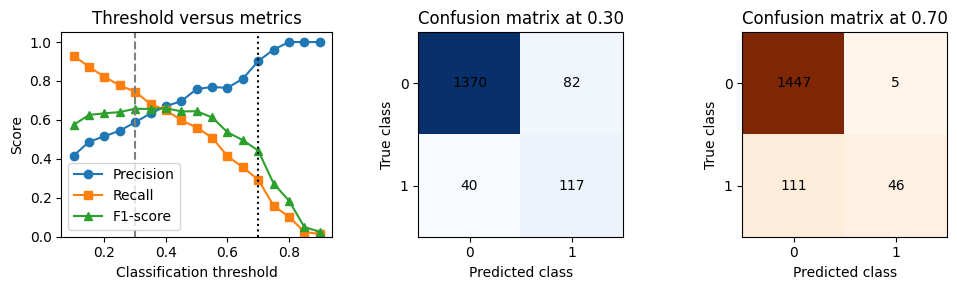

In [ ]:
#@title Python Code - Risk Threshold Selection

# This notebook studies engineering risk thresholds.
# We use Landsat data for rare events.
# Thresholds change actions and model tradeoffs.

# Load core libraries for this lesson.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import tensorflow as tf

# Import helper tools for evaluation.
from sklearn.metrics import precision_score, recall_score
from sklearn.metrics import f1_score, confusion_matrix

from sklearn.model_selection import train_test_split

# Set seeds for reproducible results.
np.random.seed(7)
tf.random.set_seed(7)

print("TensorFlow version:", tf.__version__)

# Download the Landsat dataset quietly.
!wget -q -O landsat_train.data "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/satimage/sat.trn"
!wget -q -O landsat_test.data "https://archive.ics.uci.edu/ml/machine-learning-databases/statlog/satimage/sat.tst"

# Read training and testing files.
train_df = pd.read_csv("landsat_train.data", header=None, sep=r"\s+")

test_df = pd.read_csv("landsat_test.data", header=None, sep=r"\s+")

# Combine both parts for simplicity.
full_df = pd.concat([train_df, test_df], ignore_index=True)
if full_df.shape[1] != 37:

    raise ValueError("Unexpected Landsat column count.")

# Create a rare event target.
X = full_df.iloc[:, :-1].astype("float32").copy()
y_raw = full_df.iloc[:, -1].astype(int).copy()

y = (y_raw == 4).astype("float32")

# Check class balance briefly.
rare_rate = float(y.mean())
if len(X) < 100:

    raise ValueError("Dataset is too small.")

# Split data into train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X.values, y.values, test_size=0.25,

    random_state=7, stratify=y.values)

# Standardize features using training statistics.
train_mean = X_train.mean(axis=0)
train_std = X_train.std(axis=0) + 1e-6

X_train = (X_train - train_mean) / train_std
X_test = (X_test - train_mean) / train_std

# Build a small neural network.
model = tf.keras.Sequential([
    tf.keras.layers.Input(shape=(36,)),

    tf.keras.layers.Dense(24, activation="relu"),
    tf.keras.layers.Dense(12, activation="relu"),
    tf.keras.layers.Dense(1, activation="sigmoid")])

# Compile with stable training settings.
model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),

    loss="binary_crossentropy",
    metrics=[tf.keras.metrics.AUC(name="auc")])

# Use early stopping for stability.
early_stop = tf.keras.callbacks.EarlyStopping(
    monitor="val_loss", patience=4,

    restore_best_weights=True)

# Train silently on the small model.
history = model.fit(
    X_train, y_train, epochs=25,

    batch_size=64, validation_split=0.2,
    callbacks=[early_stop], verbose=0)

# Predict calibrated style probabilities.
y_prob = model.predict(X_test, verbose=0).ravel()
if y_prob.shape[0] != y_test.shape[0]:

    raise ValueError("Prediction size mismatch.")

# Evaluate many possible thresholds.
thresholds = np.linspace(0.1, 0.9, 17)
precisions = []

recalls = []
f1_scores = []

# Compute metrics across thresholds.
for t in thresholds:
    y_pred = (y_prob >= t).astype(int)

    p = precision_score(y_test, y_pred, zero_division=0)
    r = recall_score(y_test, y_pred, zero_division=0)
    f = f1_score(y_test, y_pred, zero_division=0)
    
    precisions.append(p)
    recalls.append(r)
    f1_scores.append(f)

# Compare two engineering decision thresholds.
low_t = 0.30
high_t = 0.70

y_low = (y_prob >= low_t).astype(int)
y_high = (y_prob >= high_t).astype(int)
cm_low = confusion_matrix(y_test, y_low)

cm_high = confusion_matrix(y_test, y_high)

# Print a short engineering summary.
print("Rare event rate:", round(rare_rate, 3))
print("Test samples:", int(len(y_test)))

print("Threshold 0.30 precision:", round(precision_score(y_test, y_low, zero_division=0), 3))
print("Threshold 0.30 recall:", round(recall_score(y_test, y_low, zero_division=0), 3))
print("Threshold 0.70 precision:", round(precision_score(y_test, y_high, zero_division=0), 3))

print("Threshold 0.70 recall:", round(recall_score(y_test, y_high, zero_division=0), 3))

print("CM 0.30:", cm_low.tolist())
print("CM 0.70:", cm_high.tolist())

# Create one figure with all visuals.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot threshold versus key metrics.
axes[0].plot(thresholds, precisions, marker="o", label="Precision")
axes[0].plot(thresholds, recalls, marker="s", label="Recall")

axes[0].plot(thresholds, f1_scores, marker="^", label="F1-score")

axes[0].axvline(low_t, color="gray", linestyle="--")
axes[0].axvline(high_t, color="black", linestyle=":")

axes[0].set_title("Threshold versus metrics")
axes[0].set_xlabel("Classification threshold")
axes[0].set_ylabel("Score")

axes[0].set_ylim(0, 1.05)
axes[0].legend()

# Show confusion matrix for lower threshold.
axes[1].imshow(cm_low, cmap="Blues")
axes[1].set_title("Confusion matrix at 0.30")

axes[1].set_xlabel("Predicted class")
axes[1].set_ylabel("True class")

axes[1].set_xticks([0, 1])
axes[1].set_yticks([0, 1])

axes[1].text(0, 0, str(cm_low[0, 0]), ha="center", va="center")
axes[1].text(1, 0, str(cm_low[0, 1]), ha="center", va="center")
axes[1].text(0, 1, str(cm_low[1, 0]), ha="center", va="center")

axes[1].text(1, 1, str(cm_low[1, 1]), ha="center", va="center")

# Show confusion matrix for higher threshold.
axes[2].imshow(cm_high, cmap="Oranges")
axes[2].set_title("Confusion matrix at 0.70")

axes[2].set_xlabel("Predicted class")
axes[2].set_ylabel("True class")

axes[2].set_xticks([0, 1])
axes[2].set_yticks([0, 1])

axes[2].text(0, 0, str(cm_high[0, 0]), ha="center", va="center")
axes[2].text(1, 0, str(cm_high[0, 1]), ha="center", va="center")
axes[2].text(0, 1, str(cm_high[1, 0]), ha="center", va="center")

axes[2].text(1, 1, str(cm_high[1, 1]), ha="center", va="center")

# Finish the single required figure.
plt.tight_layout()
plt.show()

### **3.3. Confidence and Error Bands**

<img src="https://cdn.jsdelivr.net/gh/mhrafiei/contents@main/JHU/Artificial Intelligence in Civil Engineering Applications/Module_08/Lecture_B/image_03_03.jpg?v=1775531368" width="250">



>* Bands show prediction uncertainty and variability.
>* Wider bands signal higher decision risk.

>* Band width shows prediction certainty limits.
>* Bounds support realistic decisions, not guarantees.

>* Link uncertainty bands to engineering decisions.
>* Explain limits and assumptions behind bands.



TensorFlow version: 2.21.0
--2026-04-08 23:35:40--  https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls
Resolving archive.ics.uci.edu (archive.ics.uci.edu)... 128.195.10.252
Connecting to archive.ics.uci.edu (archive.ics.uci.edu)|128.195.10.252|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: unspecified
Saving to: ‘Concrete_Data.xls.1’

Concrete_Data.xls.1     [ <=>                ] 122.00K   705KB/s    in 0.2s    

2026-04-08 23:35:40 (705 KB/s) - ‘Concrete_Data.xls.1’ saved [124928]

           Metric  Value
              MAE   4.47
             RMSE   5.75
               R2   0.88
     Mean run std   2.13
   90% error band   9.30
Interval coverage   0.90


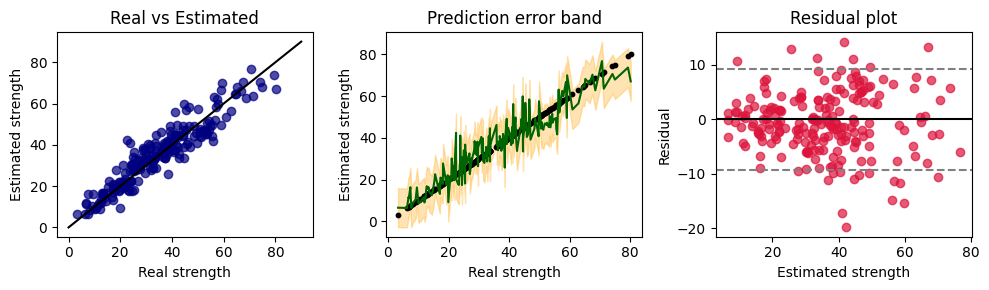

In [16]:
#@title Python Code - Confidence and Error Bands

# This notebook shows uncertainty bands simply.
# Concrete strength predictions include useful risk ranges.
# We use repeated training for uncertainty.

# Download the concrete dataset safely.
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt

# Import TensorFlow and helper tools.
import tensorflow as tf
from sklearn.model_selection import train_test_split

from sklearn.preprocessing import StandardScaler

# Import simple evaluation metrics.
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error

from sklearn.metrics import r2_score

# Set deterministic seeds carefully.
np.random.seed(7)
tf.random.set_seed(7)

# Print one short version line.
print("TensorFlow version:", tf.__version__)

# Download data if missing.
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/concrete/compressive/Concrete_Data.xls

# Read the spreadsheet dataset.
df = pd.read_excel("Concrete_Data.xls")

# Rename columns for easier use.
df.columns = [
    "cement", "slag", "fly_ash", "water",

    "superplasticizer", "coarse_agg", "fine_agg",
    "age", "strength"]

# Split inputs and target.
X = df.drop("strength", axis=1).copy()
y = df["strength"].copy()

# Create train and test sets.
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=7)

# Scale features for stable training.
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Build a small regression model.
def make_model(input_dim):

    model = tf.keras.Sequential([
        tf.keras.layers.Input(shape=(input_dim,)),
        tf.keras.layers.Dense(32, activation="relu"),

        tf.keras.layers.Dense(16, activation="relu"),
        tf.keras.layers.Dense(1)])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=0.01),
        loss="mse")

    return model

# Train several models for uncertainty.
prediction_runs = []
run_count = 5

# Repeat training with early stopping.
for run in range(run_count):

    tf.random.set_seed(7 + run)
    np.random.seed(7 + run)
    model = make_model(X_train_scaled.shape[1])

    early_stop = tf.keras.callbacks.EarlyStopping(
        monitor="val_loss", patience=15,
        restore_best_weights=True)

    history = model.fit(
        X_train_scaled, y_train,
        validation_split=0.2,

        epochs=120, batch_size=32,
        verbose=0, callbacks=[early_stop])

    preds = model.predict(X_test_scaled, verbose=0).reshape(-1)
    prediction_runs.append(preds)

# Combine repeated predictions.
prediction_runs = np.array(prediction_runs)
pred_mean = prediction_runs.mean(axis=0)

pred_std = prediction_runs.std(axis=0)

# Estimate empirical residual uncertainty.
residuals = y_test.to_numpy() - pred_mean
abs_residual = np.abs(residuals)

error_band = np.percentile(abs_residual, 90)

# Build simple prediction intervals.
lower_band = pred_mean - error_band
upper_band = pred_mean + error_band

# Compute summary metrics.
mae = mean_absolute_error(y_test, pred_mean)
rmse = np.sqrt(mean_squared_error(y_test, pred_mean))

r2 = r2_score(y_test, pred_mean)
coverage = np.mean(
    (y_test.to_numpy() >= lower_band) &

    (y_test.to_numpy() <= upper_band))

# Create a small summary table.
summary = pd.DataFrame({
    "Metric": [

        "MAE", "RMSE", "R2",
        "Mean run std", "90% error band", "Interval coverage"],
    "Value": [

        round(float(mae), 2), round(float(rmse), 2),
        round(float(r2), 2), round(float(pred_std.mean()), 2),
        round(float(error_band), 2), round(float(coverage), 2)]})

# Print a compact uncertainty summary.
print(summary.to_string(index=False))

# Sort points for cleaner bands.
sort_idx = np.argsort(y_test.to_numpy())
y_sorted = y_test.to_numpy()[sort_idx]

pred_sorted = pred_mean[sort_idx]
low_sorted = lower_band[sort_idx]
up_sorted = upper_band[sort_idx]

res_sorted = residuals[sort_idx]

# Create one figure with three panels.
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Plot real versus estimated values.
axes[0].scatter(y_test, pred_mean, color="navy", alpha=0.7)
axes[0].plot([0, 90], [0, 90], color="black")

axes[0].set_title("Real vs Estimated")
axes[0].set_xlabel("Real strength")
axes[0].set_ylabel("Estimated strength")

# Plot prediction band around estimates.
axes[1].plot(y_sorted, pred_sorted, color="darkgreen")
axes[1].fill_between(

    y_sorted, low_sorted, up_sorted,
    color="orange", alpha=0.3)

axes[1].scatter(y_sorted, y_sorted, color="black", s=10)
axes[1].set_title("Prediction error band")
axes[1].set_xlabel("Real strength")

axes[1].set_ylabel("Estimated strength")

# Plot residuals for uncertainty communication.
axes[2].scatter(pred_mean, residuals, color="crimson", alpha=0.7)
axes[2].axhline(0, color="black")

axes[2].axhline(error_band, color="gray", linestyle="--")
axes[2].axhline(-error_band, color="gray", linestyle="--")
axes[2].set_title("Residual plot")

axes[2].set_xlabel("Estimated strength")
axes[2].set_ylabel("Residual")

# Finish the single required plot.
plt.tight_layout()
plt.show()

# <font color="#418FDE" size="6.5" uppercase>**Training Stability and Risk**</font>


In this lecture, you learned to:
- Identify signs of unstable or poorly converging model training in CE workflows. 
- Stabilize training using learning rate adjustment, early stopping, and regularization. 
- Communicate model uncertainty using calibrated probabilities, thresholds, and simple visualizations. 

In the next Module (Module 9), we will go over 'Computer Vision in Civil Engineering'